Idea:

- Turn each meal into Darts' series with time as covariate
- Each restaurant corresponds with a dedicated forecasting model

In [1]:
%cd ../../

/Users/hoangle/Projects/untangling-people/ylva/fwo_models


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import holidays
from statsmodels.graphics.tsaplots import plot_acf
import polars as pl
from darts.models import NaiveMovingAverage, LinearRegressionModel, RandomForest, CatBoostModel, XGBModel, LightGBMModel
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler, StaticCovariatesTransformer, MissingValuesFiller, InvertibleMapper
from darts.dataprocessing import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})


In [4]:
K = 2
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)

# Load dims and raw data

## dim `meals`

In [5]:
dim_meals = pl.read_parquet("data/processed/phase_4/dim_meals.parquet")
dim_meals.head()

meal_id,meal_type,schoolyear,restaurant,attributes,aliases
i64,str,str,list[str],list[str],list[str]
9017,"""vegan""","""24-25""","[""che"", ""exa"", ""vik""]","[""vegan-miscellaneous"", ""kela""]","[""""Butter"" härkäpapua & pähkinää""]"
7201,"""vegan""","""23-24""",null,[],"[""2023 Härkäpu-sienilasagnette""]"
9032,"""vegan""","""23-24""",null,[],"[""Appelisiini-luomukikhernecurrya""]"
9102,"""vegan""","""23-24""",null,[],"[""Artisokkavugetteja & tuoretomaattisalsaa""]"
7010,"""vegetarian""","""24-25""","[""che"", ""exa"", ""vik""]",[],"[""Aurajuusto-pinaattilasagnette"", ""Aurajuusto-pinaattilasagnettea""]"


## dim `meal_types`

In [6]:
dim_meal_types = (
    dim_meals.select('meal_id', 'meal_type')
)
dim_meal_types.head()

meal_id,meal_type
i64,str
9017,"""vegan"""
7201,"""vegan"""
9032,"""vegan"""
9102,"""vegan"""
7010,"""vegetarian"""


## dim `meal_names`

In [7]:
dim_meal_names = (
    dim_meals
    .select(
        'meal_id',
        pl.col('aliases').alias('meal')
    )
    .explode('meal')
)
dim_meal_names.head()

meal_id,meal
i64,str
9017,"""""Butter"" härkäpapua & pähkinää"""
7201,"""2023 Härkäpu-sienilasagnette"""
9032,"""Appelisiini-luomukikhernecurry…"
9102,"""Artisokkavugetteja & tuoretoma…"
7010,"""Aurajuusto-pinaattilasagnette"""


## dim `opentime`

In [8]:
dim_opentime = (
    pl
    .from_records([
        {'restaurant': 'che', 'time_open': '10:30', 'time_close': '15:00'},
        {'restaurant': 'exa', 'time_open': '11:00', 'time_close': '14:00'},
        {'restaurant': 'phy', 'time_open': '10:00', 'time_close': '15:00'},
        {'restaurant': 'vik', 'time_open': '10:30', 'time_close': '14:00'},
    ])
    .select(
        'restaurant',
        pl.col('time_open').str.to_datetime("%H:%M"),
        pl.col('time_close').str.to_datetime("%H:%M")
    )
    .with_columns(
        ((pl.col('time_close') - pl.col('time_open')).dt.total_minutes() / 60.).alias('working_duration')
    )
)

dim_opentime.head()

restaurant,time_open,time_close,working_duration
str,datetime[μs],datetime[μs],f64
"""che""",0001-01-01 10:30:00,0001-01-01 15:00:00,4.5
"""exa""",0001-01-01 11:00:00,0001-01-01 14:00:00,3.0
"""phy""",0001-01-01 10:00:00,0001-01-01 15:00:00,5.0
"""vik""",0001-01-01 10:30:00,0001-01-01 14:00:00,3.5


## dim `exam`

In [9]:
DATE_START = pl.lit('2023-01-02').str.to_date()
DATE_END = pl.lit('2024-10-31').str.to_date()

In [10]:
dim_exam_raw = (
    pl
    .from_records([
        {'date_begin': '2023-03-06', 'date_end': '2023-03-12'},
        {'date_begin': '2023-05-01', 'date_end': '2023-05-07'},
        {'date_begin': '2023-10-23', 'date_end': '2023-10-29'},
        {'date_begin': '2023-12-18', 'date_end': '2023-12-24'},
        {'date_begin': '2024-03-04', 'date_end': '2024-03-10'},
        {'date_begin': '2024-05-06', 'date_end': '2024-05-12'},
        {'date_begin': '2024-10-21', 'date_end': '2024-10-27'},
    ])
    .with_columns(
        pl.col('date_begin').str.to_date(),
        pl.col('date_end').str.to_date(),
    )
)


df = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_START, DATE_END, '1d').alias('date')
    )
)

entries_exam = (
    df
    .join(dim_exam_raw, how='cross')
    .filter(
        (pl.col('date') >= pl.col('date_begin'))
        & (pl.col('date') <= pl.col('date_end'))
    )
    .select(
        'date',
        pl.lit(True).alias('is_exam')
    )
)
dim_exam = (
    df
    .join(entries_exam, on='date', how='left')
    .with_columns(pl.col('is_exam').fill_null(False).cast(pl.Int32))

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

dim_exam.head()

date,is_exam
date,i32
2023-01-02,0
2023-01-03,0
2023-01-04,0
2023-01-05,0
2023-01-06,0


## dim `holiday`

In [11]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday_raw = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])


dim_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_START, DATE_END, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday_raw, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('is_holiday'))
    .drop('name_holiday')

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

dim_holiday.head()

date,is_holiday
date,i32
2023-01-02,0
2023-01-03,0
2023-01-04,0
2023-01-05,0
2023-01-06,1


## raw POS

In [12]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)



# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )


    # Get meal_id
    .join(dim_meal_names, on='meal', how='left')


    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)



# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
pos = (
    pos
    .join(
        dim_meals.select('meal_id', 'meal_type'),
        on='meal_id',
        how='left'
    )
)



# Ignore buffet
pos = pos.filter(pl.col('meal_type') != pl.lit('buffet'))




# Remove pos of leftover meals
# pos = (
#     pos
#     .with_columns(
#         pl.col('date').shift(1).over('restaurant', 'meal_id', order_by='date').alias('date_lag'),
#         pl.col('pcs').shift(1).over('restaurant', 'meal_id', order_by='date').alias('pcs_lag'),
#     )
#     .filter(
#         (pl.col('date_lag').is_null())
#         | ((pl.col('date') - pl.col('date_lag')).dt.total_days() > 7)
#     )
#     .drop('date_lag', 'pcs_lag')
# )


# Keep records whose POS value is greater than Q1 value
# pos = (
#     pos
#     .with_columns(
#         pl.col('pcs').quantile(.25).over('restaurant', 'meal_id', order_by='date').alias('pcs_q1')
#     )
#     .filter(pl.col('pcs') >= pl.col('pcs_q1'))
#     .drop('pcs_q1')
# )



# Keep records whose serving_percent is greater than THETA
# THETA = .1         # this is the 1st quartile of raw data
# pos = (
#     pos
#     .filter(pl.col('serving_percent') >= THETA)
#     # .drop('serving_percent')
# )


pos.head()


restaurant,date,meal_id,pcs,serving_percent,meal_type
str,date,i64,i64,f64,str
"""exa""",2023-09-11,90000010,120,0.45,"""chicken"""
"""phy""",2024-01-12,6096,4,0.433333,"""vegan"""
"""phy""",2023-03-02,1510,8,1.126667,"""meat"""
"""phy""",2024-10-24,90000005,6,0.373333,"""chicken"""
"""vik""",2023-02-28,5081,30,0.461905,"""meat"""


In [13]:
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)

## dim `reference`

In [14]:
# dim_meal_embds = pl.read_parquet("data/inter/meal_names_embds.parquet")
# dim_meal_embds = pl.read_parquet("data/processed/embedding_tuning/meal_embds_02-27_12-04-54.parquet")
dim_meal_embds = pl.read_parquet("data/processed/embedding_tuning/meal_embds_02-26_15-35-10.parquet")

embds_1 = np.vstack(dim_meal_embds.get_column('embedding_encoded').to_numpy())
dist = 1 - (embds_1 @ embds_1.T).flatten()

dim_dist = dim_meal_embds.select('meal_id')
dim_dist = dim_dist.join(dim_dist, how='cross')

# Add distance
dim_dist = dim_dist.with_columns(pl.Series(dist).alias('dist'))
dim_dist.head()

meal_id,meal_id_right,dist
i64,i64,f32
7588,7588,0.0
7588,7581,0.004009
7588,996,0.017248
7588,6135,1.416953
7588,6874,1.448539


In [15]:
dim_reference = (
    dim_meals

    .select('meal_id', 'meal_type', 'restaurant')

    # Remove null records
    .drop_nulls()

    # Expand
    .explode('restaurant')
)


dim_reference = (
    dim_reference
    .join(dim_reference, how='cross')


    # Only keep records having different meal id
    .filter(pl.col('meal_id') != pl.col('meal_id_right'))

    # Only keep records having same meal_type and restaurant
    .filter(
        (pl.col('meal_type') == pl.col('meal_type_right'))
        & ((pl.col('restaurant') == pl.col('restaurant_right')))
    )

    # Add distance for each record
    .join(
        dim_dist,
        on=['meal_id', 'meal_id_right'],
        how='left'
    )
)




# Only keep references whose the targets already appear in train set

pcs_median = (
    pos_train
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').mean().alias('pcs_median'))

    .rename({
        'restaurant': 'restaurant_right',
        'meal_type': 'meal_type_right',
        'meal_id': 'meal_id_right',
    })
)
dim_reference = (
    dim_reference
    .join(
        pcs_median,
        on=['restaurant_right', 'meal_type_right', 'meal_id_right'],
        how='inner'
    )
)



# For each meal, only keep K
dim_reference = (
    dim_reference
    .with_columns(
        pl.col('dist').rank(descending=False).over('meal_id', 'restaurant', 'meal_type').alias('rank')
    )
    .filter(pl.col('rank') <= K)

    .select(
        pl.col('restaurant'),
        pl.col('meal_id').alias('meal'),
        pl.col('meal_id_right').alias('meal_ref'),
        'dist', 'pcs_median',
    )
)



dim_reference.head()

restaurant,meal,meal_ref,dist,pcs_median
str,i64,i64,f32,f64
"""che""",9017,7200,0.003366,118.32
"""che""",9017,7203,0.004795,81.0
"""exa""",9017,7200,0.003366,91.428571
"""exa""",9017,7203,0.004795,58.0
"""vik""",9017,7200,0.003366,65.357143


## dim `coexist`

In [16]:
topN_restaurant = pl.from_dicts([
    {'restaurant': 'che', 'topN': 3},
    {'restaurant': 'vik', 'topN': 3},
    {'restaurant': 'exa', 'topN': 3},
    {'restaurant': 'phy', 'topN': 3},
])

dim_coexist = (
    pos

    .join(topN_restaurant, on='restaurant')


    # .filter(
    #     (pl.col('restaurant') == pl.lit("vik"))
    #     & (pl.col('date') == pl.lit('2023-05-24').str.to_date())
    # )


    .with_columns(
        pl.col('pcs').rank(descending=True, method='ordinal').over('restaurant', 'date').alias('rank')
    )
    .filter(
        pl.col('rank') <= pl.col('topN')
    )

    .select('restaurant', 'date', 'meal_id')
)


meals_coexist = (
    dim_coexist
    .group_by('restaurant', 'date')
    .agg(
        pl.concat_list('meal_id').flatten().alias('meals_coexist')
    )
)
dim_coexist = (
    dim_coexist

    .join(meals_coexist, on=['restaurant', 'date'])
    .with_columns(
        pl.col('meals_coexist').list.sample(fraction=1, shuffle=True)
    )
    .explode('meals_coexist')
    .filter(pl.col('meal_id') != pl.col('meals_coexist'))
    .with_columns(
        pl.format(
            "coexist_{}",
            pl.int_range(pl.len()).over('restaurant', 'date', 'meal_id')
        ).alias('coexist'),
    )
    .pivot(
        on='coexist',
        index=['restaurant', 'date', 'meal_id'],
        values='meals_coexist'
    )

    # .filter(pl.any_horizontal(pl.all().is_null()))
)

dim_coexist.head()

restaurant,date,meal_id,coexist_0,coexist_1
str,date,i64,i64,i64
"""exa""",2023-09-11,90000010,90000069,90000045
"""vik""",2023-02-28,5081,7004,90000053
"""vik""",2023-11-20,1317,6673,7591
"""vik""",2023-10-18,90000146,7610,7579
"""phy""",2024-06-03,916,1512,1509


# Build Time series

In [17]:
col_tgt = 'pcs'

cols_cov_date = [
    # 'weekday',
    'day',
    'month',
    'year',

    'weekday_sin',
    'weekday_cos',
    'day_of_month_sin',
    'day_of_month_cos',
    # 'day_of_year_sin',
    # 'day_of_year_cos',
    'month_sin',
    'month_cos',
]

cols_cov_other = [
    'serving_percent',
    'is_exam',
    # 'is_holiday'
]

restaurant = "che"

In [18]:
map_mealtype2id = {
    "vegan": 0,
    "fish": 1,
    "vegetarian": 2,
    "chicken": 3,
    "meat": 4,
}

pos_agg = (
    pos

    .filter(
        (1 == 1)
        & (pl.col('restaurant') == pl.lit(restaurant))
    )

    # Add other info
    .join(dim_exam, on='date', how='left')
    .join(dim_holiday, on='date', how='left')

    .with_columns(pl.col('meal_type').replace(map_mealtype2id).cast(pl.Int32))

    .select(
        'meal_id',
        'meal_type',
        *[pl.struct('date', col).alias(col) for col in cols_cov_other],
        pl.struct('date', 'pcs').alias('pcs'),
    )
    .group_by('meal_id', 'meal_type')
    .agg(
        pl.concat_list('pcs').flatten(),
        *[pl.concat_list(col).flatten() for col in cols_cov_other]
    )
)

pos_agg.head()

meal_id,meal_type,pcs,serving_percent,is_exam
i64,i32,list[struct[2]],list[struct[2]],list[struct[2]]
7610,0,"[{2024-01-18,172}, {2024-05-24,37}, … {2023-12-07,203}]","[{2024-01-18,1.144444}, {2024-05-24,0.288889}, … {2023-12-07,0.925926}]","[{2024-01-18,0}, {2024-05-24,0}, … {2023-12-07,0}]"
6546,0,"[{2024-09-10,104}, {2024-09-11,71}, {2024-07-30,117}]","[{2024-09-10,0.974074}, {2024-09-11,0.985185}, {2024-07-30,0.751852}]","[{2024-09-10,0}, {2024-09-11,0}, {2024-07-30,0}]"
90000042,3,"[{2024-08-16,37}, {2024-01-17,385}, … {2023-08-02,227}]","[{2024-08-16,0.614815}, {2024-01-17,1.07037}, … {2023-08-02,0.981481}]","[{2024-08-16,0}, {2024-01-17,0}, … {2023-08-02,0}]"
6159,0,"[{2024-04-08,223}, {2024-01-16,50}, … {2023-12-07,56}]","[{2024-04-08,1.081481}, {2024-01-16,0.274074}, … {2023-12-07,0.833333}]","[{2024-04-08,0}, {2024-01-16,0}, … {2023-12-07,0}]"
90000039,1,"[{2023-08-16,217}, {2023-07-06,28}, … {2024-06-28,10}]","[{2023-08-16,1.040741}, {2023-07-06,0.340741}, … {2024-06-28,0.259259}]","[{2023-08-16,0}, {2023-07-06,0}, … {2024-06-28,0}]"


In [19]:
DATE_FORECAST = pd.to_datetime("2024-09-01")

series_pair = {}

for entry in pos_agg.iter_rows(named=True):

    df = pd.DataFrame.from_records(entry['pcs']).sort_values('date')
    for idx, col in enumerate(cols_cov_other):
        df = df.merge(
            pd.DataFrame.from_records(entry[col]).sort_values('date'),
            on='date',
            how='inner'
        )

    if len(df) == 0:
        continue

    
    df['date'] = pd.to_datetime(df['date']) 
    df['weekday'] = df['date'].dt.weekday
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['weekday_sin'] = np.sin(df['date'].dt.weekday * 2 * np.pi / 7)
    df['weekday_cos'] = np.cos(df['date'].dt.weekday * 2 * np.pi / 7)
    df['day_of_month_sin'] = np.sin(df['date'].dt.day * 2 * np.pi / 31)
    df['day_of_month_cos'] = np.cos(df['date'].dt.day * 2 * np.pi / 31)
    df['day_of_year_sin'] = np.sin(df['date'].dt.day * 2 * np.pi / 365)
    df['day_of_year_cos'] = np.cos(df['date'].dt.day * 2 * np.pi / 365)
    df['month_sin'] = np.sin(df['date'].dt.month * 2 * np.pi / 12)
    df['month_cos'] = np.cos(df['date'].dt.month * 2 * np.pi / 12)

    n_train = len(df[df['date'] < DATE_FORECAST])
    n_forecast = len(df[df['date'] >= DATE_FORECAST])
    dates_forecast = df[df['date'] >= DATE_FORECAST]['date']

    if n_forecast == 0 or n_train < 3:
        continue

    
    series_tgt = TimeSeries.from_dataframe(
        df,
        value_cols=col_tgt,
        fillna_value=False,
        static_covariates=pd.DataFrame(data={"meal_type": [entry['meal_type']]})
    )
    series_cov_date = TimeSeries.from_dataframe(
        df,
        value_cols=cols_cov_date + cols_cov_other,
        fillna_value=False,
        # static_covariates=df['school_id']
    )

    series_pair[entry['meal_id']] = {
        'dates': df['date'],
        'tgt': series_tgt,
        'cov': series_cov_date,
        'n_forecast': n_forecast,
        'dates_forecast': dates_forecast
    }


## Global model

<Axes: xlabel='importance', ylabel='name'>

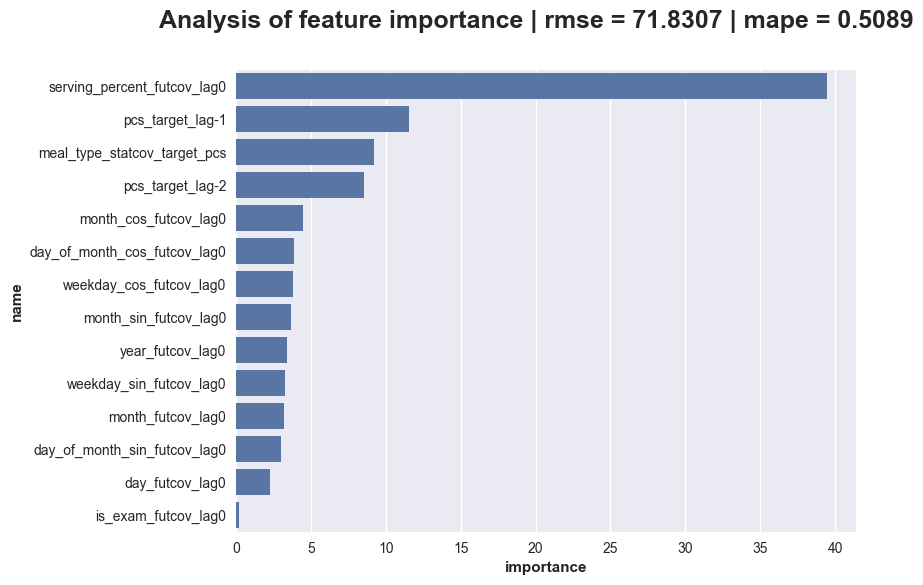

In [ ]:
keys, series_train_list, series_val_list, future_cov_list = [], [], [], []
for k, entry in series_pair.items():
    dates = entry['dates']
    
    series = entry['tgt']
    tgt_train, tgt_val = series.split_before(len(series) - entry['n_forecast'])


    keys.append(k)
    series_train_list.append(tgt_train)
    series_val_list.append(tgt_val)
    future_cov_list.append(entry['cov'])


series_train_list = series_train_list
future_cov_list = future_cov_list

model = CatBoostModel(
    lags=2,
    lags_future_covariates=[0],
    output_chunk_length=1,
)
model.fit(series_train_list, future_covariates=future_cov_list)
preds = model.predict(1, series=series_train_list, future_covariates=future_cov_list)


preds_list = []
for key, pred, series_val in zip(keys, preds, series_val_list):
    df_pred = pd.DataFrame({
        'meal_id': key,
        # 'date': entry['dates_forecast'].tolist(),
        'gt': series_val.to_dataframe()['pcs'].tolist()[0],
        'pred': pred.to_dataframe()['pcs'].tolist(),
    })

    preds_list.append(df_pred)

preds_df = pd.concat(preds_list)
preds_df['pred'] = preds_df['pred'].clip(0)
preds_df['ape'] = np.abs(preds_df['pred'] - preds_df['gt']) / preds_df['gt']


rmse = root_mean_squared_error(preds_df['gt'], preds_df['pred'])
mape = mean_absolute_percentage_error(preds_df['gt'], preds_df['pred'])


feat_imp = pd.DataFrame({
    'name': model.lagged_feature_names,
    'importance': model.model.feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
fig.suptitle(f"Analysis of feature importance | rmse = {rmse:.4f} | mape = {mape:.4f}", fontsize=18, fontweight='bold')
ax = fig.add_subplot(111)
sns.barplot(feat_imp, y='name', x='importance', ax=ax)

In [21]:
preds_df.sort_values('ape', ascending=False).head()

,meal_id,gt,pred,ape
0,6088,20.0,113.704667,4.685233
0,7560,33.0,155.699243,3.718159
0,90000057,8.0,-18.623319,3.327915
0,907,79.0,269.087864,2.406175
0,90000017,48.0,106.697791,1.222871


### Plot

<Axes: xlabel='date', ylabel='pcs'>

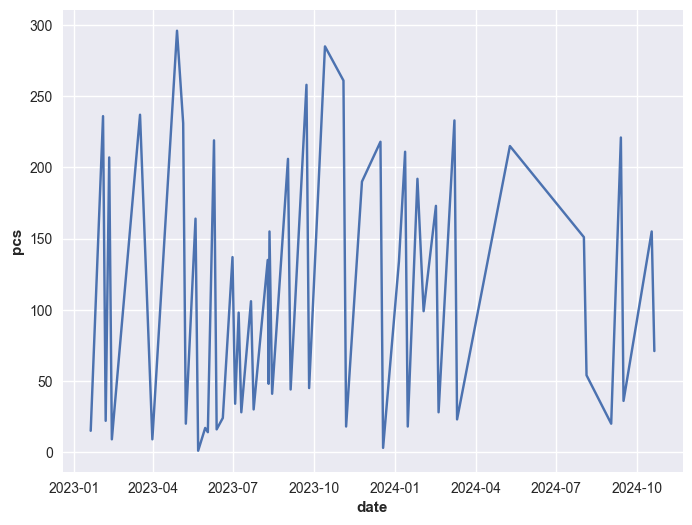

In [22]:
entry = series_pair[6088]

df = entry['tgt'].to_dataframe().reset_index()
df['date'] = entry['dates'].tolist()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

sns.lineplot(df, x='date', y='pcs')

## Moving average

In [23]:
preds_list = []

for key, entry in series_pair.items():
    pipeline = Pipeline([
        InvertibleMapper(np.log1p, np.expm1, verbose=False, n_jobs=-1, name="Log-Transform"),
        Scaler(verbose=False, n_jobs=-1, name="Scaling"),
    ])

    series = entry['tgt']
    tgt_train, tgt_val = entry['tgt'].split_before(len(series) - entry['n_forecast'])

    model = NaiveMovingAverage(min(5, len(tgt_train)))
    # model = ARIMA()
    model.fit(tgt_train)
    preds = model.predict(1)
    # preds = pipeline.inverse_transform(preds)

    df_pred = pd.DataFrame({
        'meal_id': key,
        'date': entry['dates_forecast'].tolist()[0],
        'gt': tgt_val.to_dataframe()['pcs'].tolist()[0],
        'pred': preds.to_dataframe()['pcs'].tolist(),
    })

    preds_list.append(df_pred)

preds_df = pd.concat(preds_list)

# preds_df.head()

rmse = root_mean_squared_error(preds_df['gt'], preds_df['pred'])
mape = mean_absolute_percentage_error(preds_df['gt'], preds_df['pred'])

print(f"rmse: {rmse:.4f}")
print(f"mape: {mape:.4f}")


rmse: 99.2058
mape: 0.5820


<Axes: xlabel='time'>

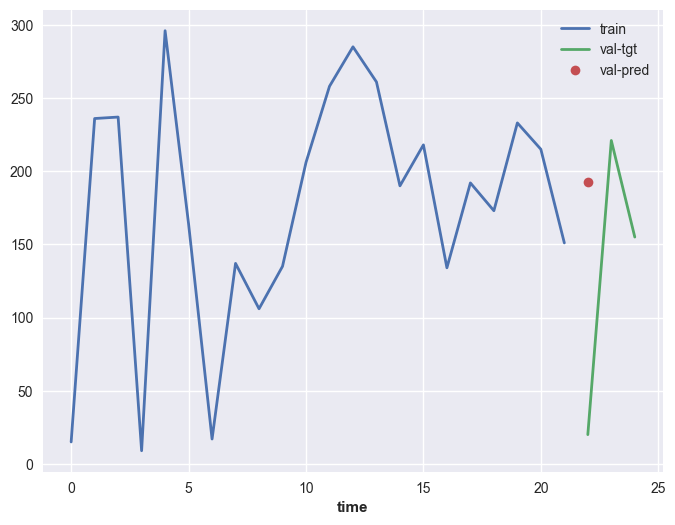

In [26]:
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)

# _ = plot_acf(entry['tgt'].to_dataframe()['pcs'], ax=ax)

entry = series_pair[6088]

series = entry['tgt']
tgt_train, tgt_val = entry['tgt'].split_before(len(series) - entry['n_forecast'])

model = NaiveMovingAverage(min(5, len(tgt_train)))
# model = ARIMA()
model.fit(tgt_train)
preds = model.predict(1)
# preds = pipeline.inverse_transform(preds)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

tgt_train.plot(ax=ax, label='train')
tgt_val.plot(ax=ax, label='val-tgt')
preds.plot(ax=ax, label='val-pred')